# PCG Baseline Model
A PCG-only 1D CNN for HFrEF prediction. The processed data is split at the subject level to prevent data leakage and handle class imbalance using a weighted loss function.

The input has 4 channels (APEX, LLSB, LUSB, RUSB), with 30 seconds for each channel, sampled at 4000 Hz. Run the preprocessing notebook first; it prepares the test set too.

In [1]:
import os
import sys
import json
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
from tqdm import tqdm

from torch.utils.data import DataLoader

PROJECT_DIR = os.path.abspath('..') if os.path.isdir('../src') else os.path.abspath('.')
if PROJECT_DIR not in sys.path:
    sys.path.append(PROJECT_DIR)
from src.data_loader import ProcessedCardioDataset, get_dataloaders
from src.pcg_model import PCG_Encoder
from src.preprocessing import CHANNEL_ORDER, PCG_FS, PCG_SAMPLES

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

PROCESSED_DIR = os.path.join(PROJECT_DIR, 'data/processed/patient_4ch/development')
metadata_path = os.path.join(PROCESSED_DIR, 'processed_metadata.csv')
if not os.path.isfile(metadata_path):
    raise FileNotFoundError('Run 1_preprocessing.ipynb first to save the patient tensors.')
metadata = pd.read_csv(metadata_path, dtype={'Patient_ID': str})

VALIDATION_FOLD = 0
assert metadata['Patient_ID'].is_unique
assert metadata['Fold'].isin(range(5)).all()

train_df = metadata[metadata['Fold'] != VALIDATION_FOLD].reset_index(drop=True)
val_df = metadata[metadata['Fold'] == VALIDATION_FOLD].reset_index(drop=True)

assert set(train_df['Patient_ID']).isdisjoint(val_df['Patient_ID'])
assert set(train_df['Label']) == {0, 1}
assert set(val_df['Label']) == {0, 1}

print(f"Training patients: {len(train_df)}")
print(f"Validation patients: {len(val_df)}")

Training patients: 400
Validation patients: 100


C:\Users\BluRay\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Initialize Dataloaders and Model
PyTorch `.pt` tensors are directly loaded from disk.

Each PCG tensor is `(4, 120000)` before batching — 8x longer than the ECG tensors, since PCG is sampled at 4000 Hz vs ECG's 500 Hz. The stem in `PCG_Encoder` downsamples more aggressively to compensate, so the final sequence length before pooling matches the ECG model's (469).

In [2]:
batch_size = 16

train_loader, val_loader = get_dataloaders(
    train_df, val_df, data_dir=PROCESSED_DIR, batch_size=batch_size,
    modality='pcg', seed=SEED,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model_config = {'in_channels': 4, 'feature_dim': 128, 'dropout': 0.3}
pcg_model = PCG_Encoder(**model_config).to(device)

sample_pcg, sample_labels = next(iter(val_loader))
assert sample_pcg.shape[1:] == (4, PCG_SAMPLES)

print(f"DataLoaders ready. Training batches: {len(train_loader)}")
print(f"Model initialized on device: {device}")
print(f"Input shape: {sample_pcg.shape}")

DataLoaders ready. Training batches: 25


Model initialized on device: cuda
Input shape: torch.Size([16, 4, 120000])


## Training Loop
Same class imbalance as the ECG baseline (~440 Non-HFrEF to ~60 HFrEF across folds), so we reuse Focal Loss, AdamW, a plateau LR scheduler, and early stopping — all architecture-agnostic, unchanged from the ECG notebook.

### Focal Loss
$$ FL(p_t) = -\alpha_t (1 - p_t)^\gamma \log(p_t) $$

In [3]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.88, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        bce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        probs = torch.sigmoid(inputs)
        pt = torch.where(targets == 1, probs, 1 - probs)
        alpha_t = torch.where(targets == 1, self.alpha, 1 - self.alpha)
        focal_loss = alpha_t * (1 - pt) ** self.gamma * bce_loss
        return focal_loss.mean()

In [4]:
MODEL_DIR = os.path.join(PROJECT_DIR, 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

num_epochs = 50
learning_rate = 1e-3
weight_decay = 1e-4
patience = 10

focal_alpha = float((train_df['Label'] == 0).mean())
criterion = FocalLoss(alpha=focal_alpha, gamma=2.0).to(device)
optimizer = optim.AdamW(pcg_model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

best_auroc = -float('inf')
epochs_without_improvement = 0
history = []
MODEL_SAVE_PATH = os.path.join(MODEL_DIR, f'best_pcg_4ch_fold{VALIDATION_FOLD}.pt')

for epoch in range(num_epochs):
    pcg_model.train()
    train_loss = 0.0

    for pcg, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
        pcg = pcg.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer.zero_grad(set_to_none=True)
        outputs = pcg_model(pcg)
        loss = criterion(outputs, labels)

        if not torch.isfinite(loss):
            raise ValueError("Training loss is not finite.")
        loss.backward()
        nn.utils.clip_grad_norm_(pcg_model.parameters(), max_norm=1.0, error_if_nonfinite=True)
        optimizer.step()
        train_loss += loss.item() * pcg.size(0)

    epoch_train_loss = train_loss / len(train_loader.dataset)

    pcg_model.eval()
    val_loss = 0.0
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for pcg, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]"):
            pcg = pcg.to(device)
            labels = labels.to(device).unsqueeze(1)

            outputs = pcg_model(pcg)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * pcg.size(0)

            preds = torch.sigmoid(outputs)
            all_labels.extend(labels.cpu().numpy().ravel())
            all_preds.extend(preds.cpu().numpy().ravel())

    epoch_val_loss = val_loss / len(val_loader.dataset)

    auroc = roc_auc_score(all_labels, all_preds)
    auprc = average_precision_score(all_labels, all_preds)

    print(f"Epoch {epoch+1} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | AUROC: {auroc:.4f} | AUPRC: {auprc:.4f}")

    history.append({
        'epoch': epoch + 1,
        'train_loss': epoch_train_loss,
        'val_loss': epoch_val_loss,
        'val_auroc': auroc,
        'val_auprc': auprc,
        'lr': optimizer.param_groups[0]['lr'],
    })
    scheduler.step(auroc)

    if auroc > best_auroc:
        print(f"Validation AUROC improved from {best_auroc:.4f} to {auroc:.4f}. Saving improved model.")
        best_auroc = auroc
        epochs_without_improvement = 0
        torch.save(pcg_model.state_dict(), MODEL_SAVE_PATH)
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f"Early stopping. Best validation AUROC: {best_auroc:.4f}")
            break

pcg_model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device, weights_only=True))
pcg_model.eval()

history = pd.DataFrame(history)
history.to_csv(MODEL_SAVE_PATH.replace('.pt', '.history.csv'), index=False)

Epoch 1/50 [Train]:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 1/50 [Train]:   4%|▍         | 1/25 [00:00<00:13,  1.76it/s]

Epoch 1/50 [Train]:   8%|▊         | 2/25 [00:00<00:07,  2.97it/s]

Epoch 1/50 [Train]:  12%|█▏        | 3/25 [00:00<00:05,  3.96it/s]

Epoch 1/50 [Train]:  16%|█▌        | 4/25 [00:01<00:04,  4.75it/s]

...

Epoch 12/50 [Val]:  57%|█████▋    | 4/7 [00:00<00:00,  8.82it/s]

Epoch 12/50 [Val]:  71%|███████▏  | 5/7 [00:00<00:00,  8.98it/s]

Epoch 12/50 [Val]:  86%|████████▌ | 6/7 [00:00<00:00,  9.03it/s]

Epoch 12/50 [Val]: 100%|██████████| 7/7 [00:00<00:00, 10.00it/s]

Epoch 12 | Train Loss: 0.0059 | Val Loss: 0.1355 | AUROC: 0.5597 | AUPRC: 0.2543
Early stopping. Best validation AUROC: 0.6686


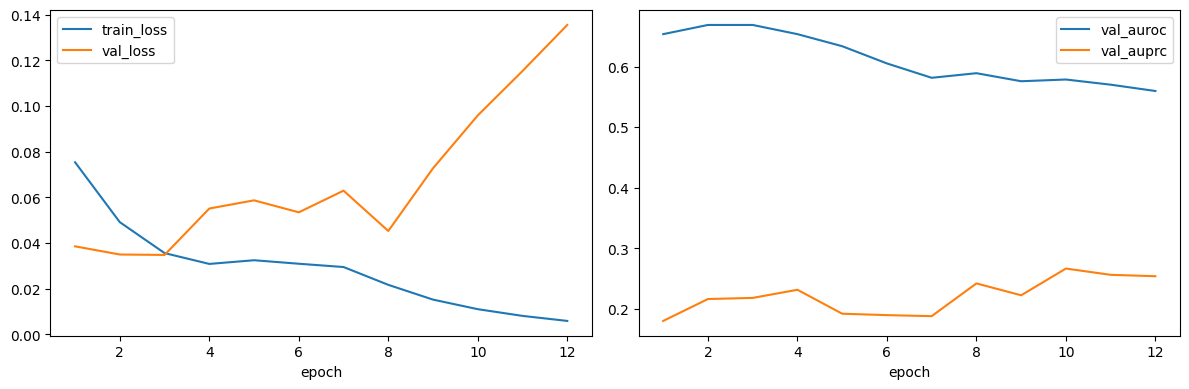

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
history.plot(x='epoch', y=['train_loss', 'val_loss'], ax=axes[0])
history.plot(x='epoch', y=['val_auroc', 'val_auprc'], ax=axes[1])
plt.tight_layout()
plt.show()

## Model Evaluation
We choose the threshold using the validation set, then keep it the same for the test set.

Optimal Probability Cutoff: 0.5013
Max F1-Score: 0.3333

Classification Report:
              precision    recall  f1-score   support

   Non-HFrEF       0.92      0.80      0.85        88
       HFrEF       0.25      0.50      0.33        12

    accuracy                           0.76       100
   macro avg       0.59      0.65      0.59       100
weighted avg       0.84      0.76      0.79       100

Confusion Matrix:
[[70 18]
 [ 6  6]]


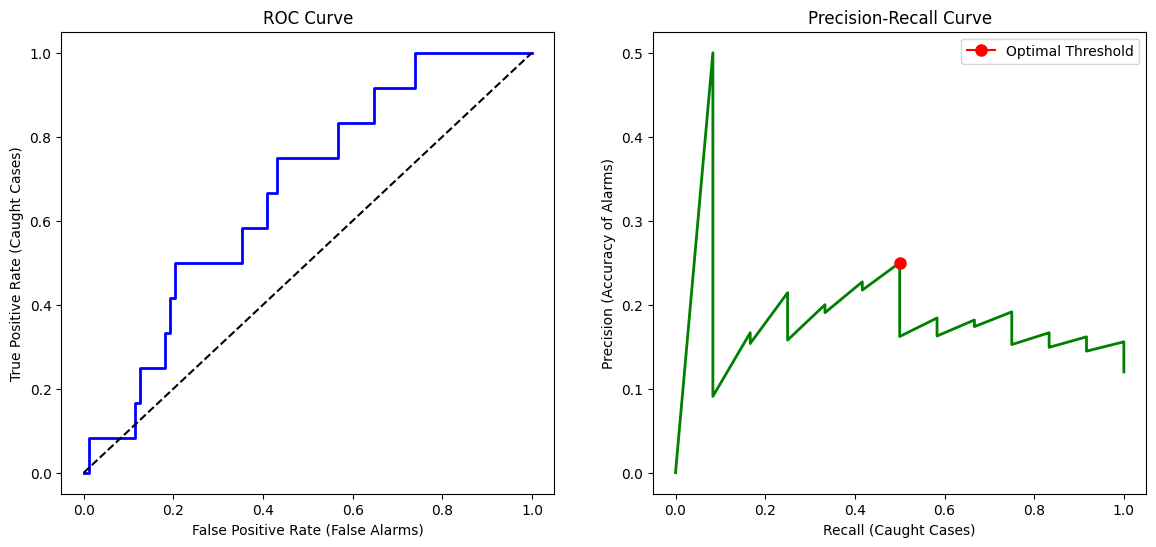

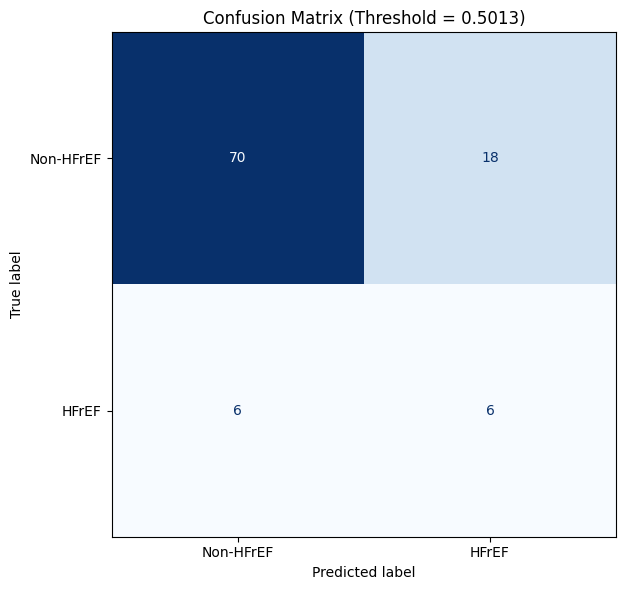

In [6]:
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix, classification_report, ConfusionMatrixDisplay

pcg_model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device, weights_only=True))
pcg_model.eval()

all_labels = []
all_preds = []
with torch.no_grad():
    for pcg, labels in val_loader:
        pcg = pcg.to(device)
        preds = torch.sigmoid(pcg_model(pcg))
        all_labels.extend(labels.cpu().numpy().ravel())
        all_preds.extend(preds.cpu().numpy().ravel())

precisions, recalls, thresholds_pr = precision_recall_curve(all_labels, all_preds)

f1_scores = (2 * precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = float(thresholds_pr[optimal_idx])

print(f"Optimal Probability Cutoff: {optimal_threshold:.4f}")
print(f"Max F1-Score: {f1_scores[optimal_idx]:.4f}")

binary_preds = (np.array(all_preds) >= optimal_threshold).astype(int)
cm = confusion_matrix(all_labels, binary_preds, labels=[0, 1])
print("\nClassification Report:")
print(classification_report(all_labels, binary_preds, labels=[0, 1], target_names=['Non-HFrEF', 'HFrEF'], zero_division=0))

fpr, tpr, thresholds_roc = roc_curve(all_labels, all_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(fpr, tpr, color='blue', lw=2)
axes[0].plot([0, 1], [0, 1], color='black', linestyle='--')
axes[0].set_xlabel('False Positive Rate (False Alarms)')
axes[0].set_ylabel('True Positive Rate (Caught Cases)')
axes[0].set_title('ROC Curve')

axes[1].plot(recalls[:-1], precisions[:-1], color='green', lw=2)
axes[1].plot(recalls[optimal_idx], precisions[optimal_idx], marker='o', markersize=8, color="red", label="Optimal Threshold")
axes[1].set_xlabel('Recall (Caught Cases)')
axes[1].set_ylabel('Precision (Accuracy of Alarms)')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

print('Confusion Matrix:')
print(cm)

fig_cm, ax_cm = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Non-HFrEF', 'HFrEF']
)
disp.plot(ax=ax_cm, cmap='Blues', colorbar=False, values_format='d')
ax_cm.set_title(f'Confusion Matrix (Threshold = {optimal_threshold:.4f})')
plt.tight_layout()
plt.show()

In [7]:
experiment = {
    'model_config': model_config,
    'channel_order': list(CHANNEL_ORDER),
    'pcg_sample_rate': PCG_FS,
    'pcg_samples': PCG_SAMPLES,
    'pcg_bandpass_hz': [25.0, 400.0],
    'normalization': 'per-channel z-score',
    'seed': SEED,
    'validation_fold': VALIDATION_FOLD,
    'threshold': optimal_threshold,
    'focal_alpha': focal_alpha,
    'focal_gamma': 2.0,
    'learning_rate': learning_rate,
    'weight_decay': weight_decay,
    'batch_size': batch_size,
    'max_epochs': num_epochs,
    'patience': patience,
    'best_epoch': int(history.loc[history['val_auroc'].idxmax(), 'epoch']),
    'train_patient_ids': train_df['Patient_ID'].tolist(),
    'validation_patient_ids': val_df['Patient_ID'].tolist(),
}
with open(MODEL_SAVE_PATH.replace('.pt', '.json'), 'w') as f:
    json.dump(experiment, f, indent=2)

## Observations on the results:

# not done yet

## Using The Test Set
- It should follow the same preprocessing steps as the training/validation data.
- This is already done in the preprocessing notebook. Here, we only load the saved files.

In [8]:
TEST_PROCESSED_DIR = os.path.join(PROJECT_DIR, 'data/processed/patient_4ch/test')
TEST_METADATA_PATH = os.path.join(TEST_PROCESSED_DIR, 'processed_metadata.csv')

if not os.path.isfile(TEST_METADATA_PATH):
    raise FileNotFoundError('Run the test preprocessing section in 1_preprocessing.ipynb first.')
test_metadata = pd.read_csv(TEST_METADATA_PATH, dtype={'Patient_ID': str})

print("Test label columns:")
print(test_metadata.columns.tolist())

print("\nFirst rows:")
print(test_metadata.head())

print("\nShape:")
print(test_metadata.shape)

assert test_metadata['Patient_ID'].is_unique
assert test_metadata['Fold'].eq(-1).all()
assert set(metadata['Patient_ID']).isdisjoint(test_metadata['Patient_ID'])

print("Test subjects:")
print(test_metadata['Label'].value_counts().sort_index())

Test label columns:
['Patient_ID', 'LVEF', 'Label', 'Fold', 'Channel_Order', 'Num_Channels', 'APEX_Record_ID', 'LLSB_Record_ID', 'LUSB_Record_ID', 'RUSB_Record_ID', 'ECG_File', 'PCG_File', 'ECG_Samples', 'PCG_Samples']

First rows:
   Patient_ID  LVEF  Label  Fold        Channel_Order  Num_Channels  \
0  1011486422  0.40      1    -1  APEX|LLSB|LUSB|RUSB             4   
1  2024031801  0.58      0    -1  APEX|LLSB|LUSB|RUSB             4   
2  2024031802  0.61      0    -1  APEX|LLSB|LUSB|RUSB             4   
3  2024031803  0.61      0    -1  APEX|LLSB|LUSB|RUSB             4   
4  2024031804  0.62      0    -1  APEX|LLSB|LUSB|RUSB             4   

    APEX_Record_ID   LLSB_Record_ID   LUSB_Record_ID   RUSB_Record_ID  \
0  1011486422_APEX  1011486422_LLSB  1011486422_LUSB  1011486422_RUSB   
1  2024031801_APEX  2024031801_LLSB  2024031801_LUSB  2024031801_RUSB   
2  2024031802_APEX  2024031802_LLSB  2024031802_LUSB  2024031802_RUSB   
3  2024031803_APEX  2024031803_LLSB  2024031803_L

### Create Dataset

In [9]:
test_dataset = ProcessedCardioDataset(test_metadata, TEST_PROCESSED_DIR, modality='pcg')

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

print(f"Test patients: {len(test_dataset)}")
print(f"Test batches: {len(test_loader)}")

Test patients: 120
Test batches: 8


## Evaluate on Test Set

In [10]:
pcg_model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device, weights_only=True))
pcg_model.eval()

test_labels = []
test_preds = []

with torch.no_grad():
    for pcg, labels in test_loader:
        pcg = pcg.to(device)

        outputs = pcg_model(pcg)
        preds = torch.sigmoid(outputs)

        test_labels.extend(labels.cpu().numpy().ravel())
        test_preds.extend(preds.cpu().numpy().ravel())

test_labels = np.array(test_labels)
test_preds = np.array(test_preds)

assert len(test_preds) == len(test_metadata)

print(f"Optimal threshold: {optimal_threshold}")

Optimal threshold: 0.5013168454170227


## Test Results

Frozen threshold: 0.5013
Test AUROC:       0.6487
Test AUPRC:       0.2559

Classification Report:
              precision    recall  f1-score   support

   Non-HFrEF     0.9694    0.8261    0.8920       115
       HFrEF     0.0909    0.4000    0.1481         5

    accuracy                         0.8083       120
   macro avg     0.5301    0.6130    0.5201       120
weighted avg     0.9328    0.8083    0.8610       120


Confusion Matrix:


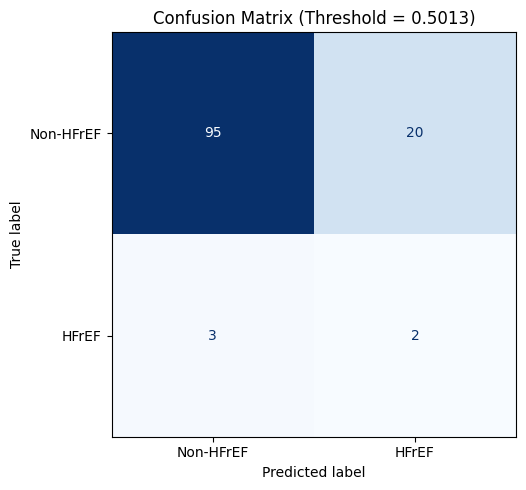

F1-Score:          0.1481
Balanced Accuracy: 0.6130
Sensitivity:       0.4000
Specificity:       0.8261


In [11]:
test_auroc = roc_auc_score(test_labels, test_preds)
test_auprc = average_precision_score(test_labels, test_preds)
test_binary_preds = (test_preds >= optimal_threshold).astype(int)
test_cm = confusion_matrix(test_labels, test_binary_preds, labels=[0, 1])

print(f"Frozen threshold: {optimal_threshold:.4f}")
print(f"Test AUROC:       {test_auroc:.4f}")
print(f"Test AUPRC:       {test_auprc:.4f}")

print("\nClassification Report:")
print(classification_report(test_labels, test_binary_preds, labels=[0, 1], target_names=['Non-HFrEF', 'HFrEF'], digits=4, zero_division=0))

fig, ax_cm = plt.subplots(figsize=(6, 5))

print("\nConfusion Matrix:")
disp = ConfusionMatrixDisplay(
    confusion_matrix=test_cm,
    display_labels=['Non-HFrEF', 'HFrEF']
)
disp.plot(ax=ax_cm, cmap='Blues', colorbar=False, values_format='d')
ax_cm.set_title(f'Confusion Matrix (Threshold = {optimal_threshold:.4f})')

plt.tight_layout()
plt.show()

from sklearn.metrics import f1_score, balanced_accuracy_score

tn, fp, fn, tp = test_cm.ravel()
print(f"F1-Score:          {f1_score(test_labels, test_binary_preds, zero_division=0):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(test_labels, test_binary_preds):.4f}")
print(f"Sensitivity:       {tp / (tp + fn) if tp + fn else float('nan'):.4f}")
print(f"Specificity:       {tn / (tn + fp) if tn + fp else float('nan'):.4f}")

test_results_df = test_metadata[['Patient_ID', 'Label']].copy()
test_results_df['Probability'] = test_preds
test_results_df['Prediction'] = test_binary_preds
test_results_df.to_csv(MODEL_SAVE_PATH.replace('.pt', '.test_predictions.csv'), index=False)